# Dimensionality reduction for selected scRNA-seq datasets

This notebook is an educational, partial reproduction inspired by Xiang et al. (2021). It compares PCA, t-SNE, UMAP, and a project-specific VAE. It is **not** a full reproduction of the paper's 10-method, multi-dataset benchmark. The README documents all known deviations.

## 1. Imports and reproducibility configuration

In [ ]:
from pathlib import Path
import random
import tarfile
from time import time
from urllib.request import urlretrieve

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import scvelo as scv
import torch
import umap
from scipy.sparse import issparse
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import (
    adjusted_mutual_info_score,
    adjusted_rand_score,
    silhouette_score,
)
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from torch import nn, optim
from torch.nn import functional as F
from torch.utils.data import DataLoader, TensorDataset

SEED = 0
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)
print(f"Device: {device}")

## 2. Dataset loading

Downloaded data are stored under the repository-relative `data/` directory and are not committed. Deng is loaded from GEO supplementary per-sample files, Chu from the GEO expected-count matrix, and PBMC68k through scVelo's dataset loader.

### 2.1 PBMC68k

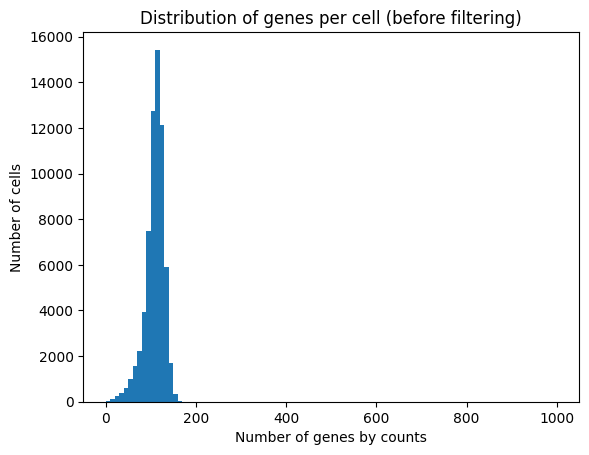

In [ ]:
PBMC_DIR = DATA_DIR / "pbmc68k"
PBMC_DIR.mkdir(parents=True, exist_ok=True)
data_pbmc = scv.datasets.pbmc68k(
    file_path=str(PBMC_DIR / "pbmc68k.h5ad")
)

adata_temp = data_pbmc.copy()
sc.pp.calculate_qc_metrics(adata_temp, inplace=True)
plt.hist(adata_temp.obs["n_genes_by_counts"], bins=100, range=(0, 1000))
plt.xlabel("Number of genes by counts")
plt.ylabel("Number of cells")
plt.title("Distribution of genes per cell before filtering")
plt.show()

In [ ]:
print(f"Original shape: {data_pbmc.shape}")
print(f"Cell-type labels: {data_pbmc.obs['celltype'].nunique()}")
print(adata_temp.obs["n_genes_by_counts"].describe())

Original shape: (65877, 33939)
Cell-type labels: 11
count    65877.000000
mean       107.948738
std         21.532068
min          0.000000
25%         98.000000
50%        111.000000
75%        122.000000
max        171.000000
Name: n_genes_by_counts, dtype: float64


### 2.2 Deng (GSE45719)

In [ ]:
DENG_DIR = DATA_DIR / "deng"
DENG_DIR.mkdir(parents=True, exist_ok=True)
DENG_ARCHIVE = DENG_DIR / "GSE45719.tar"
DENG_URL = "https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSE45719&format=file"

if not DENG_ARCHIVE.exists():
    urlretrieve(DENG_URL, DENG_ARCHIVE)

if not list(DENG_DIR.glob("*.txt.gz")):
    with tarfile.open(DENG_ARCHIVE) as archive:
        destination = DENG_DIR.resolve()
        for member in archive.getmembers():
            member_path = (DENG_DIR / member.name).resolve()
            if destination != member_path and destination not in member_path.parents:
                raise ValueError(f"Unsafe archive member: {member.name}")
        archive.extractall(DENG_DIR)

In [ ]:
files = sorted(DENG_DIR.glob("*.txt.gz"))
count_data = []
cell_names = []

for file_path in files:
    frame = pd.read_csv(file_path, sep="\t", header=None)
    frame.columns = frame.loc[0, :]
    frame = frame.drop(0, axis=0)

    parts = file_path.name.split("_")
    cell_name = parts[1] + "_" + parts[2]
    cell_names.append(cell_name)

    frame = frame[["#Gene_symbol", "reads"]].copy()
    frame.set_index("#Gene_symbol", inplace=True)
    count_data.append(pd.to_numeric(frame["reads"]))

deng_count_matrix = pd.concat(count_data, axis=1)
deng_count_matrix.columns = cell_names

In [ ]:
data_deng = ad.AnnData(deng_count_matrix.T.astype(np.float32))
source_labels = pd.Series(data_deng.obs_names).str.split("_").str[0]


def to_six_groups(label):
    label = label.lower()
    if label.startswith("zy"):
        return None
    if "2cell" in label:
        return "2-cell"
    if "4cell" in label:
        return "4-cell"
    if "8cell" in label:
        return "8-cell"
    if "16cell" in label:
        return "16-cell"
    if "blast" in label:
        return "blastocyst"
    return "other"


group_labels = np.array([to_six_groups(label) for label in source_labels])
keep_mask = np.array([label is not None for label in group_labels])
data_deng = data_deng[keep_mask].copy()
group_labels = group_labels[keep_mask]

X_deng = np.asarray(data_deng.X, dtype=np.float32)
zero_columns = np.flatnonzero(np.all(X_deng == 0, axis=0))
X_deng = np.delete(X_deng, zero_columns, axis=1)
labels_deng = LabelEncoder().fit_transform(group_labels)

print("Original data shape: (317, 22958)")
print(f"Filtered data shape: {data_deng.shape}")
print(f"Number of zygote-labelled cells removed: {(~keep_mask).sum()}")
print(f"Number of all-zero genes removed: {len(zero_columns)}")
print(f"Analysis matrix shape: {X_deng.shape}")
print(pd.Series(group_labels).value_counts().sort_index())

Original data shape: (317, 22958)
Filtered data shape: (313, 22958)
Number of zygote-labelled cells removed: 4
Number of all-zero genes removed: 1143
Analysis matrix shape: (313, 21815)
16-cell        58
2-cell         30
4-cell         14
8-cell         47
blastocyst    143
other          21
Name: count, dtype: int64


### 2.3 Chu (GSE75748; H1/H9 subset used here)

In [ ]:
CHU_DIR = DATA_DIR / "chu"
CHU_DIR.mkdir(parents=True, exist_ok=True)
CHU_FILE = CHU_DIR / "GSE75748_sc_cell_type_ec.csv.gz"
CHU_URL = (
    "https://ftp.ncbi.nlm.nih.gov/geo/series/GSE75nnn/"
    "GSE75748/suppl/GSE75748_sc_cell_type_ec.csv.gz"
)

if not CHU_FILE.exists():
    urlretrieve(CHU_URL, CHU_FILE)

chu_frame = pd.read_csv(CHU_FILE, index_col=0)
cell_type = [column.split("_")[0] for column in chu_frame.columns]
chu = ad.AnnData(
    X=chu_frame.values.T.astype(np.float32),
    obs=pd.DataFrame({"cell_type": cell_type}, index=chu_frame.columns),
    var=pd.DataFrame(index=chu_frame.index),
)

# This repository compares H1 with H9. Xiang et al. compare H1 with DEC.
embryonic_mask = chu.obs["cell_type"].isin(["H1", "H9"])
data_chu = chu[embryonic_mask].copy()
X_chu = np.asarray(data_chu.X, dtype=np.float32)
chu_labels = LabelEncoder().fit_transform(data_chu.obs["cell_type"])

print(chu)
print(data_chu)
print(data_chu.obs["cell_type"].value_counts())

AnnData object with n_obs × n_vars = 1018 × 19097
    obs: 'cell_type'
AnnData object with n_obs × n_vars = 374 × 19097
    obs: 'cell_type'
cell_type
H1    212
H9    162
Name: count, dtype: int64


## 3. Preprocessing

Preprocessing is dataset-specific in this notebook. Deng removes zygote-labelled cells and all-zero genes but otherwise uses the downloaded read-count columns. Chu selects H1/H9 cells and otherwise uses the downloaded expected-count matrix. PBMC alone receives gene/cell filtering, library-size normalization, `log1p`, selection of 2,000 highly variable genes, and feature scaling. The VAE additionally receives per-feature min-max scaling to `[0, 1]`.

In [ ]:
def normalize_pbmc(
    adata,
    *,
    min_cells=3,
    min_genes=140,
    n_top_genes=2000,
):
    """Apply the PBMC-only preprocessing used in this project."""
    adata = adata.copy()
    if issparse(adata.X):
        non_integer = (adata.X.astype(int) != adata.X).nnz
        assert non_integer == 0, "Expected integer-valued PBMC counts"
    else:
        assert np.all(adata.X.astype(int) == adata.X)

    sc.pp.filter_genes(adata, min_cells=min_cells)
    sc.pp.filter_cells(adata, min_genes=min_genes)

    counts_per_cell = np.asarray(adata.X.sum(axis=1)).ravel()
    median_counts = float(np.median(counts_per_cell))
    adata.raw = adata.copy()
    adata.obs["size_factors"] = counts_per_cell / median_counts
    sc.pp.normalize_total(adata, target_sum=median_counts)
    sc.pp.log1p(adata)
    sc.pp.highly_variable_genes(
        adata,
        min_mean=0.0125,
        max_mean=3,
        min_disp=0.5,
        n_top_genes=n_top_genes,
        subset=True,
    )
    sc.pp.scale(adata)
    return adata


normalized_pbmc = normalize_pbmc(data_pbmc)
X_pbmc = np.asarray(normalized_pbmc.X, dtype=np.float32)
pbmc_labels = LabelEncoder().fit_transform(normalized_pbmc.obs["celltype"])
print(f"PBMC analysis matrix: {X_pbmc.shape}")
print(f"PBMC cell-type labels: {len(np.unique(pbmc_labels))}")

PBMC analysis matrix: (2027, 2000)
PBMC cell-type labels: 11


## 4. Dimensionality-reduction implementations

PCA, t-SNE, and UMAP receive each dataset's analysis matrix directly; PCA is not used as preprocessing for the other methods. Evaluation uses 100 dimensions for Deng and Chu and 50 for PBMC. Separate two-dimensional runs are used only for visualization.

In [ ]:
def pca_reduce(n_components, X):
    return PCA(n_components=n_components, random_state=SEED).fit_transform(X)


def kmeans_cluster(n_clusters, X):
    return KMeans(
        n_clusters=n_clusters,
        n_init=10,
        random_state=SEED,
    ).fit_predict(X)


def tsne_reduce(n_components, X, method="barnes_hut"):
    if n_components >= 4 and method == "barnes_hut":
        method = "exact"
    if method == "exact" and issparse(X):
        raise ValueError("Exact t-SNE requires a dense matrix")
    return TSNE(
        n_components=n_components,
        init="random",
        method=method,
        random_state=SEED,
    ).fit_transform(X)


def umap_reduce(
    n_components,
    X,
    n_neighbors=15,
    min_dist=0.1,
    metric="euclidean",
):
    return umap.UMAP(
        n_components=n_components,
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        metric=metric,
        random_state=SEED,
    ).fit_transform(X)


class VAE(nn.Module):
    """A small fully connected VAE adapted from the PyTorch VAE example."""

    def __init__(self, original_dim, intermediate_dim, n_components):
        super().__init__()
        self.fc1 = nn.Linear(original_dim, intermediate_dim)
        self.fc_mu = nn.Linear(intermediate_dim, n_components)
        self.fc_logvar = nn.Linear(intermediate_dim, n_components)
        self.fc3 = nn.Linear(n_components, intermediate_dim)
        self.fc4 = nn.Linear(intermediate_dim, original_dim)

    def encode(self, x):
        hidden = F.relu(self.fc1(x))
        return self.fc_mu(hidden), self.fc_logvar(hidden)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        return mu + torch.randn_like(std) * std

    def decode(self, z):
        return torch.sigmoid(self.fc4(F.relu(self.fc3(z))))

    def forward(self, x):
        mu, logvar = self.encode(x)
        return self.decode(self.reparameterize(mu, logvar)), mu, logvar


def vae_loss(reconstructed, observed, mu, logvar):
    reconstruction = F.binary_cross_entropy(
        reconstructed, observed, reduction="sum"
    )
    kl_divergence = -0.5 * torch.sum(
        1 + logvar - mu.pow(2) - logvar.exp()
    )
    return reconstruction + kl_divergence


def vae_reduce(n_components, X, epochs=500):
    torch.manual_seed(SEED)
    original_dim = X.shape[1]
    intermediate_dim = 400
    batch_size = 128
    dummy_targets = torch.zeros(X.shape[0], device=X.device)
    dataset = TensorDataset(X, dummy_targets)
    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=True,
        generator=torch.Generator().manual_seed(SEED),
    )
    model = VAE(original_dim, intermediate_dim, n_components).to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    for epoch in range(1, epochs + 1):
        model.train()
        train_loss = 0.0
        for batch, _ in loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            reconstructed, mu, logvar = model(batch)
            loss = vae_loss(reconstructed, batch, mu, logvar)
            loss.backward()
            train_loss += loss.item()
            optimizer.step()
        if epoch == 1 or epoch % 50 == 0:
            average_loss = train_loss / len(loader.dataset)
            print(f"Epoch {epoch:03d} | average loss: {average_loss:.4f}")

    model.eval()
    with torch.no_grad():
        latent_mean, _ = model.encode(X.to(device))
    return latent_mean.cpu().numpy()


def prepare_vae_input(X):
    scaled = MinMaxScaler(clip=True).fit_transform(X)
    return torch.tensor(scaled, dtype=torch.float32, device=device)


METHODS = {
    "pca": pca_reduce,
    "tsne": tsne_reduce,
    "umap": umap_reduce,
    "vae": vae_reduce,
}

### 4.1 Project-specific VAE

The encoder is `input -> 400 (ReLU) -> latent mean/log-variance`; the decoder is `latent -> 400 (ReLU) -> input (sigmoid)`. Training uses summed binary cross-entropy plus KL divergence, Adam (`lr=1e-3`), batch size 128, and 500 epochs. This adapts the official PyTorch MNIST VAE example and is not the Keras/TensorFlow VAE implementation evaluated by Xiang et al.

In [ ]:
def synchronize_accelerator():
    if device.type == "cuda":
        torch.cuda.synchronize()
    elif device.type == "mps":
        torch.mps.synchronize()


def plot_2d(embedding, labels, method_name):
    plt.figure(figsize=(10, 8))
    plt.scatter(
        embedding[:, 0],
        embedding[:, 1],
        c=labels,
        cmap="viridis",
        alpha=0.5,
    )
    plt.title(f"K-means clusters in the {method_name} embedding")
    plt.xlabel("Component 1")
    plt.ylabel("Component 2")
    plt.colorbar(label="K-means cluster")
    plt.show()


def run_and_plot_2d(X, method_name, n_clusters):
    synchronize_accelerator()
    start = time()
    embedding = METHODS[method_name](2, X)
    synchronize_accelerator()
    elapsed = time() - start
    labels = kmeans_cluster(n_clusters, embedding)
    plot_2d(embedding, labels, method_name)
    return elapsed


def plot_metric_results(evaluation_results):
    methods = list(evaluation_results)
    metrics = [
        metric for metric in evaluation_results[methods[0]] if metric != "time"
    ]
    scores = np.array(
        [
            [evaluation_results[method][metric] for method in methods]
            for metric in metrics
        ]
    )
    x = np.arange(len(methods))
    width = 0.25
    fig, axis = plt.subplots(figsize=(12, 7))
    for index, metric in enumerate(metrics):
        offset = width * (index - (len(metrics) - 1) / 2)
        bars = axis.bar(x + offset, scores[index], width, label=metric)
        axis.bar_label(bars, padding=3, fmt="%.2f", fontsize=9)
    axis.set_ylabel("Score")
    axis.set_title("Clustering metrics by dimensionality-reduction method")
    axis.set_xticks(x)
    axis.set_xticklabels(methods)
    axis.legend(title="Metric", bbox_to_anchor=(1.04, 1), loc="upper left")
    axis.yaxis.grid(True, linestyle="--", alpha=0.7)
    fig.tight_layout()
    plt.show()

## 5. Clustering and evaluation

K-means is fit once to each reduced representation with `k` set to the number of known labels. The labels therefore determine `k` and are used for external ARI/AMI evaluation, but are not used to fit PCA, t-SNE, UMAP, or VAE. Silhouette is computed in the reduced embedding using the predicted K-means clusters. Raw cluster-label accuracy is intentionally excluded because cluster identifiers are arbitrary.

In [ ]:
def evaluate_clustering(true_labels, predicted_labels, embedding):
    """Return permutation-invariant clustering metrics.

    Silhouette is computed in the reduced embedding using predicted K-means
    clusters. Labels are not used to fit the dimensionality-reduction methods.
    """
    return {
        "AMI": adjusted_mutual_info_score(true_labels, predicted_labels),
        "ARI": adjusted_rand_score(true_labels, predicted_labels),
        "Silhouette Score": silhouette_score(embedding, predicted_labels),
    }


def evaluate_methods(
    X,
    true_labels,
    n_components,
    methods=("pca", "tsne", "umap"),
):
    n_clusters = len(np.unique(true_labels))
    results = {}
    for method_name in methods:
        print(f"Testing {method_name} + K-means...")
        synchronize_accelerator()
        start = time()
        embedding = METHODS[method_name](n_components, X)
        synchronize_accelerator()
        elapsed = time() - start
        predicted_labels = kmeans_cluster(n_clusters, embedding)
        scores = evaluate_clustering(true_labels, predicted_labels, embedding)
        scores["time"] = elapsed
        results[method_name] = scores
        print(f"  shape: {embedding.shape}")
        print(f"  {method_name} results: {scores}")
    return results

## 6. Saved results from the original notebook run

The outputs below were retained from the notebook committed before this reproducibility cleanup. In that run, t-SNE used `random_state=0`, but UMAP, K-means, and VAE did not have fixed seeds. The cleaned code above fixes seeds for future runs, so exact values and plots may differ. The README reports the saved ARI, AMI, silhouette, and timing values with this limitation; it does not present them as regenerated results.

### 6.1 Deng

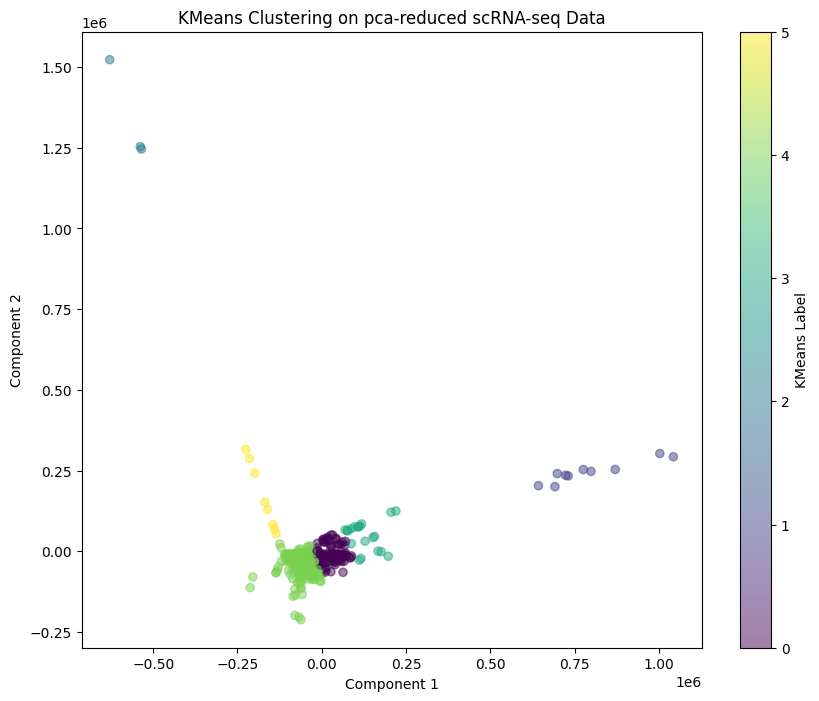

time = 0.5447537899017334


In [ ]:
deng_pca_time = run_and_plot_2d(X_deng, "pca", n_clusters=6)
print(f"time = {deng_pca_time}")

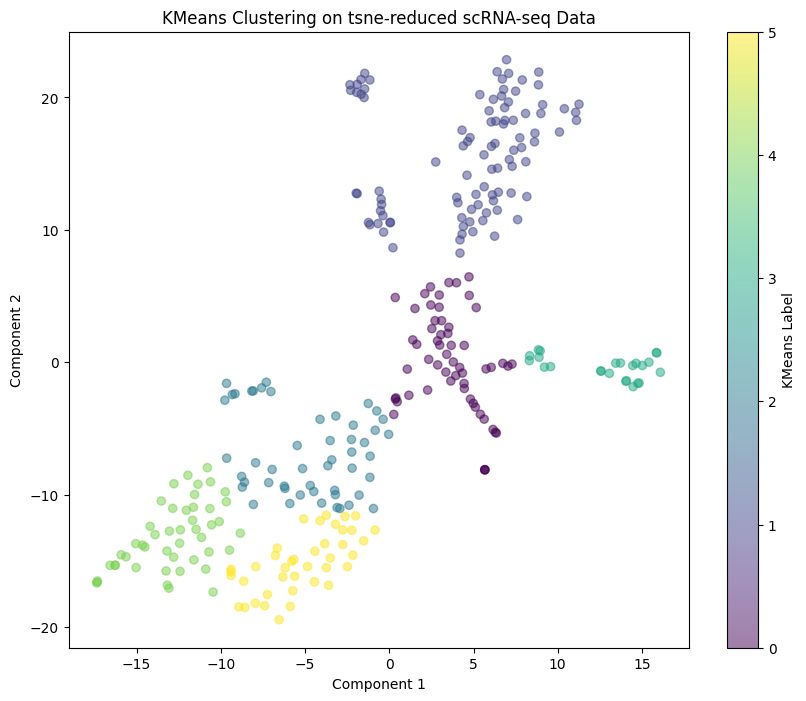

time = 1.6733014583587646


In [ ]:
deng_tsne_time = run_and_plot_2d(X_deng, "tsne", n_clusters=6)
print(f"time = {deng_tsne_time}")

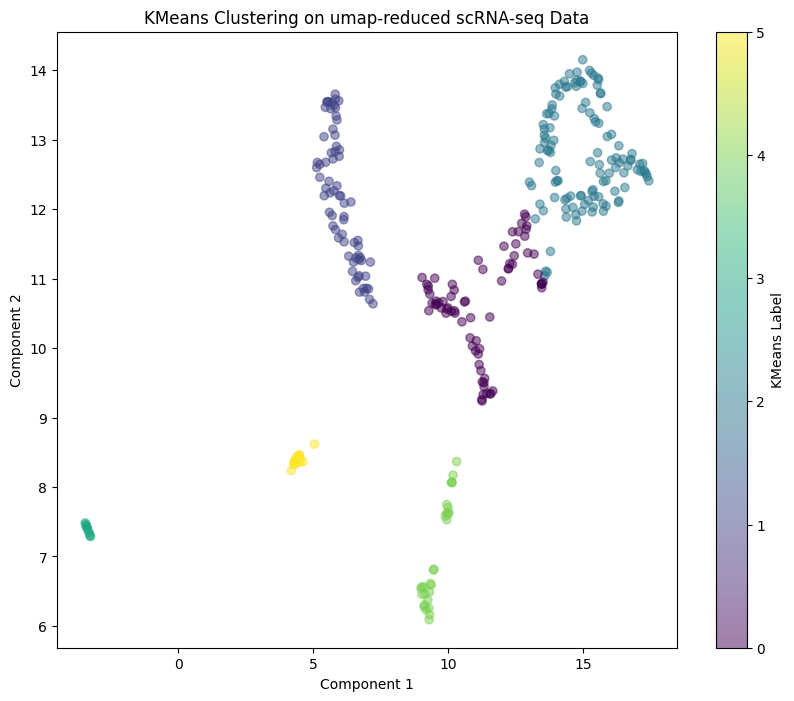

time = 9.022167921066284


In [ ]:
deng_umap_time = run_and_plot_2d(X_deng, "umap", n_clusters=6)
print(f"time = {deng_umap_time}")

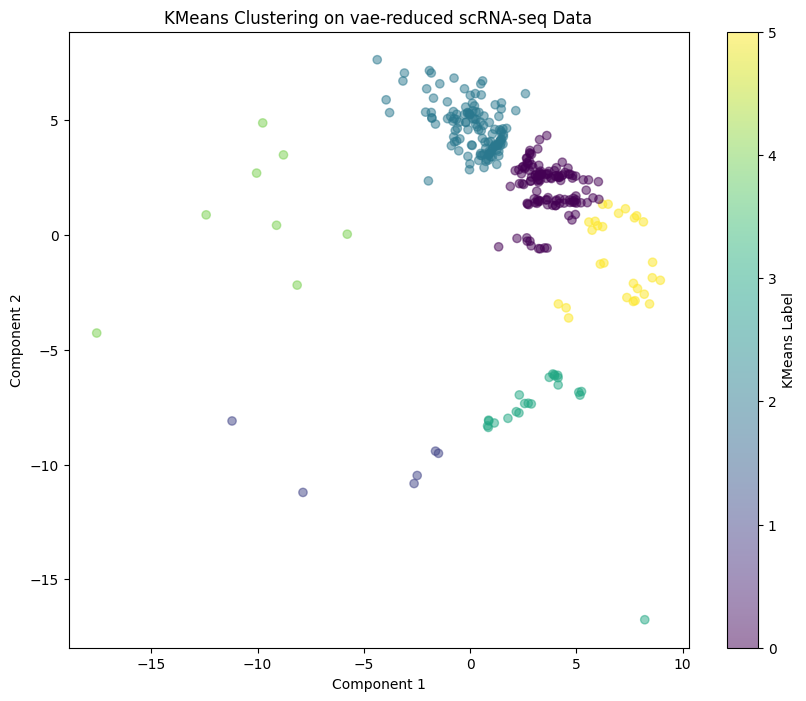

In [ ]:
X_deng_vae = prepare_vae_input(X_deng)
deng_vae_time = run_and_plot_2d(X_deng_vae, "vae", n_clusters=6)

In [ ]:
deng_results = evaluate_methods(
    X_deng, labels_deng, n_components=100
)
deng_results

6
Testing pca + KMeans...
(313, 100)
  pca results: {'AMI': np.float64(0.33220674936299915), 'ARI': 0.11526364894504199, 'Silhouette Score': np.float32(0.3051357), 'time': 1.1646931171417236}
Testing tsne + KMeans...
(313, 100)
  tsne results: {'AMI': np.float64(0.33920286564368685), 'ARI': 0.2253394728891951, 'Silhouette Score': np.float32(0.12752055), 'time': 17.775462865829468}
Testing umap + KMeans...
(313, 100)
  umap results: {'AMI': np.float64(0.6943797078894774), 'ARI': 0.7652220072393247, 'Silhouette Score': np.float32(0.68400085), 'time': 1.339308261871338}

Overall Evaluation Results:
pca: {'AMI': np.float64(0.33220674936299915), 'ARI': 0.11526364894504199, 'Silhouette Score': np.float32(0.3051357), 'time': 1.1646931171417236}
tsne: {'AMI': np.float64(0.33920286564368685), 'ARI': 0.2253394728891951, 'Silhouette Score': np.float32(0.12752055), 'time': 17.775462865829468}
umap: {'AMI': np.float64(0.6943797078894774), 'ARI': 0.7652220072393247, 'Silhouette Score': np.float32(0.

In [ ]:
deng_vae_results = evaluate_methods(
    X_deng_vae, labels_deng, n_components=100, methods=("vae",)
)
deng_results.update(deng_vae_results)

Testing vae + KMeans...
(313, 100)
  vae results: {'AMI': np.float64(0.3741452812171713), 'ARI': 0.23753931838326972, 'Silhouette Score': np.float32(0.04142906), 'time': 13.180485486984253}


In [ ]:
plot_metric_results(deng_results)

### 6.2 PBMC68k filtered/HVG subset

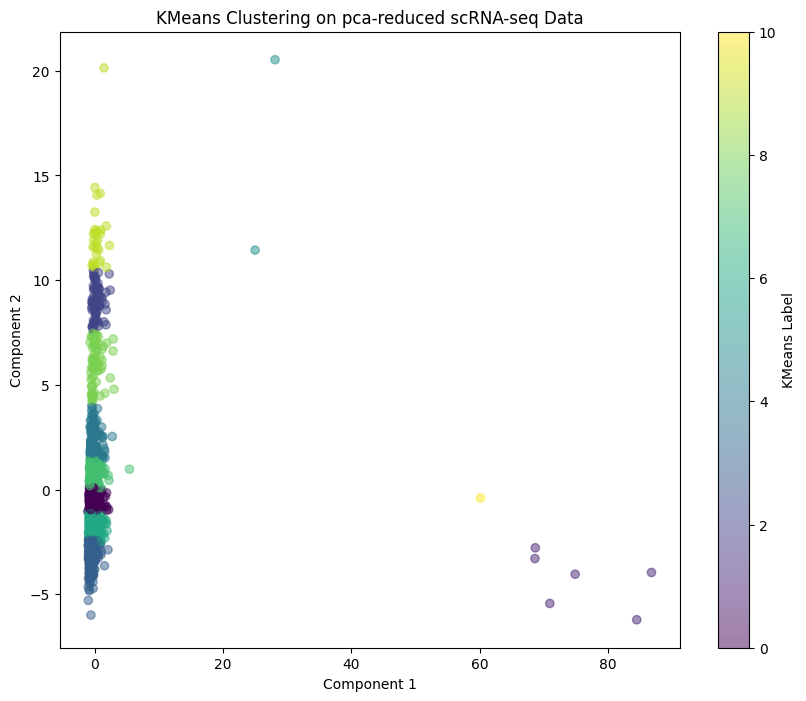

time: 0.8450088500976562


In [ ]:
pbmc_pca_time = run_and_plot_2d(X_pbmc, "pca", n_clusters=11)
print(f"time = {pbmc_pca_time}")

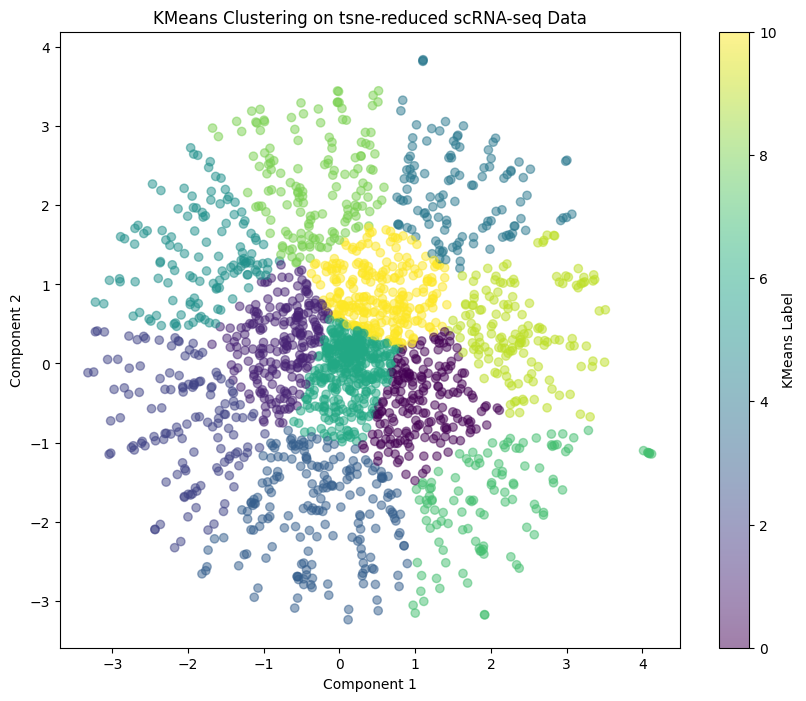

time: 29.781370639801025


In [ ]:
pbmc_tsne_time = run_and_plot_2d(X_pbmc, "tsne", n_clusters=11)
print(f"time = {pbmc_tsne_time}")

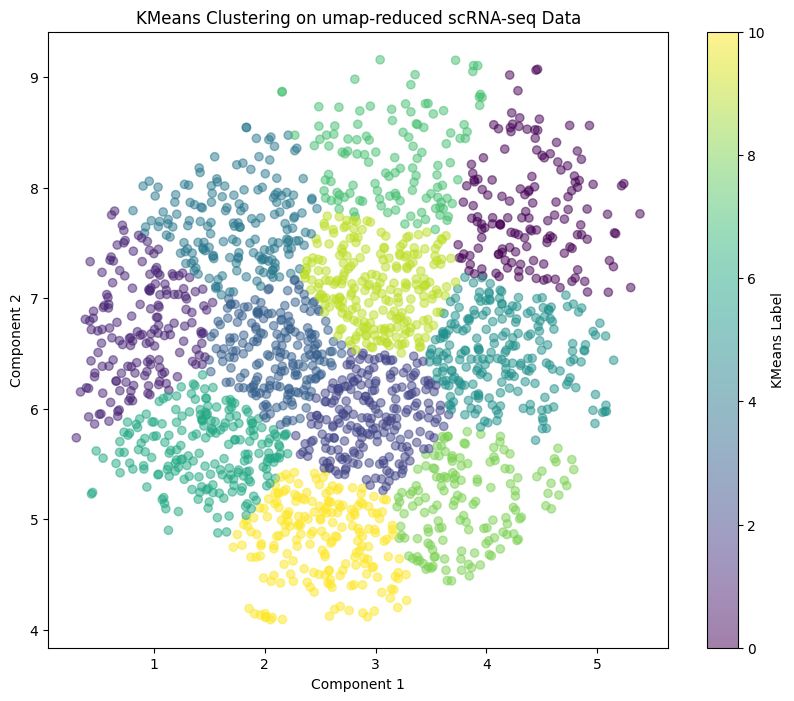

time: 5.729387283325195


In [ ]:
pbmc_umap_time = run_and_plot_2d(X_pbmc, "umap", n_clusters=11)
print(f"time = {pbmc_umap_time}")

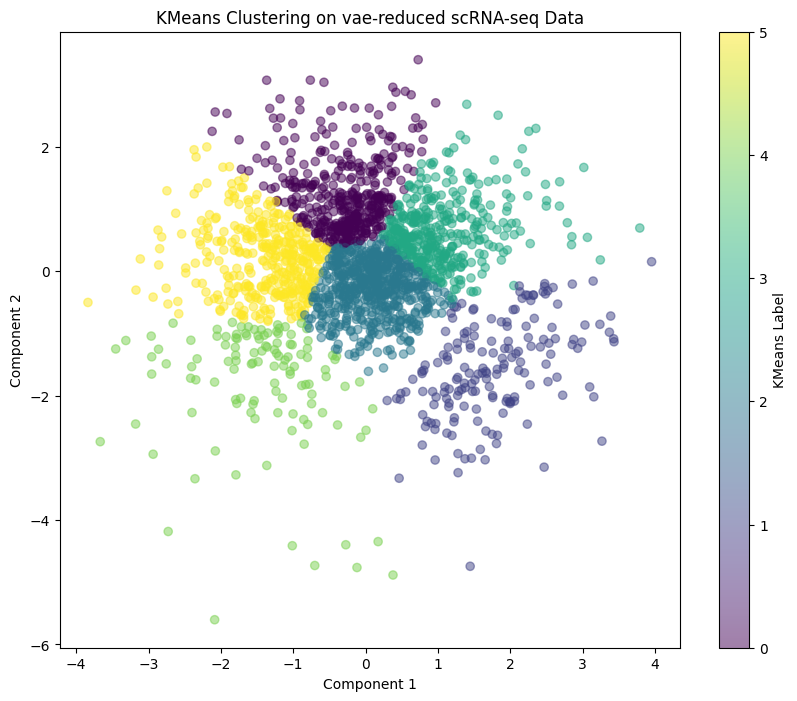

In [ ]:
X_pbmc_vae = prepare_vae_input(X_pbmc)
pbmc_vae_time = run_and_plot_2d(X_pbmc_vae, "vae", n_clusters=11)

In [ ]:
pbmc_results = evaluate_methods(
    X_pbmc, pbmc_labels, n_components=50
)
pbmc_results

Testing pca + KMeans...
(2027, 50)
  pca results: {'AMI': np.float64(0.4356397527015242), 'ARI': 0.5383188383315484, 'Silhouette Score': np.float64(0.06594244386247805), 'time': 0.9348247051239014}
Testing tsne + KMeans...
(2027, 50)
  tsne results: {'AMI': np.float64(0.07017608779836053), 'ARI': 0.02336152073493953, 'Silhouette Score': np.float32(0.04866736), 'time': 426.2895085811615}
Testing umap + KMeans...
(2027, 50)
  umap results: {'AMI': np.float64(0.021613148194830095), 'ARI': 0.00650387666552886, 'Silhouette Score': np.float32(0.1974503), 'time': 9.514284133911133}

Overall Evaluation Results:
pca: {'AMI': np.float64(0.4356397527015242), 'ARI': 0.5383188383315484, 'Silhouette Score': np.float64(0.06594244386247805), 'time': 0.9348247051239014}
tsne: {'AMI': np.float64(0.07017608779836053), 'ARI': 0.02336152073493953, 'Silhouette Score': np.float32(0.04866736), 'time': 426.2895085811615}
umap: {'AMI': np.float64(0.021613148194830095), 'ARI': 0.00650387666552886, 'Silhouette Sc

In [ ]:
pbmc_vae_results = evaluate_methods(
    X_pbmc_vae, pbmc_labels, n_components=50, methods=("vae",)
)
pbmc_results.update(pbmc_vae_results)

Testing vae + KMeans...
(2027, 50)
  vae results: {'AMI': np.float64(0.23570393011168686), 'ARI': 0.07065856248490338, 'Silhouette Score': np.float32(0.02241092), 'time': 30.922431468963623}


In [ ]:
plot_metric_results(pbmc_results)

### 6.3 Chu H1/H9 subset

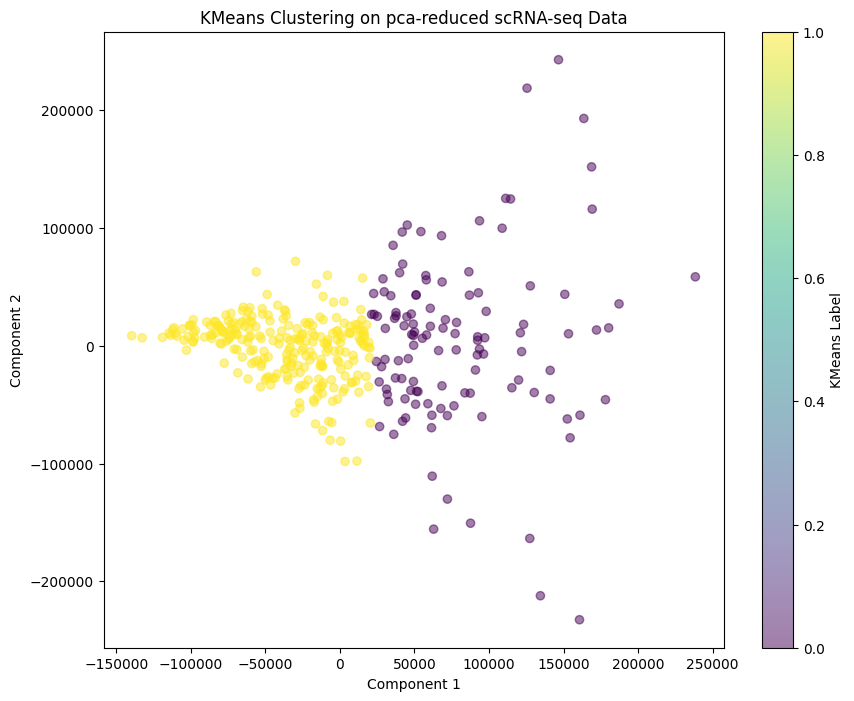

time = 0.38994312286376953


In [ ]:
chu_pca_time = run_and_plot_2d(X_chu, "pca", n_clusters=2)
print(f"time = {chu_pca_time}")

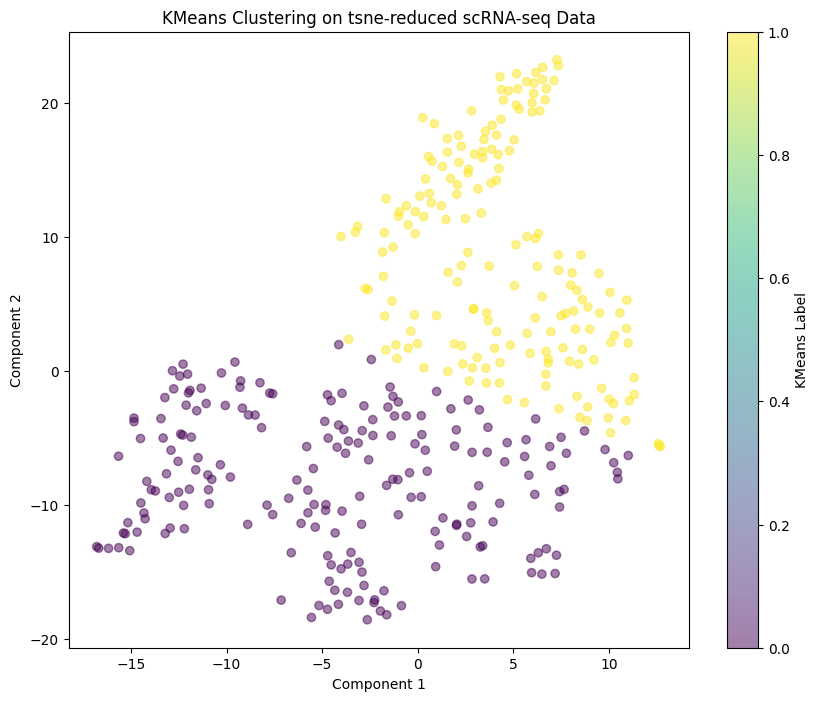

time = 2.078611135482788


In [ ]:
chu_tsne_time = run_and_plot_2d(X_chu, "tsne", n_clusters=2)
print(f"time = {chu_tsne_time}")

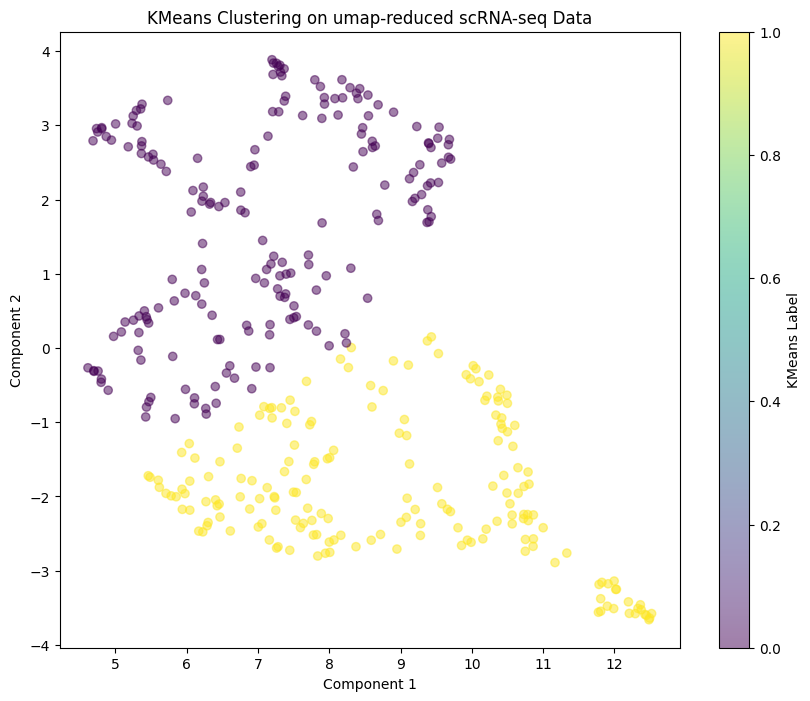

time = 1.3228895664215088


In [ ]:
chu_umap_time = run_and_plot_2d(X_chu, "umap", n_clusters=2)
print(f"time = {chu_umap_time}")

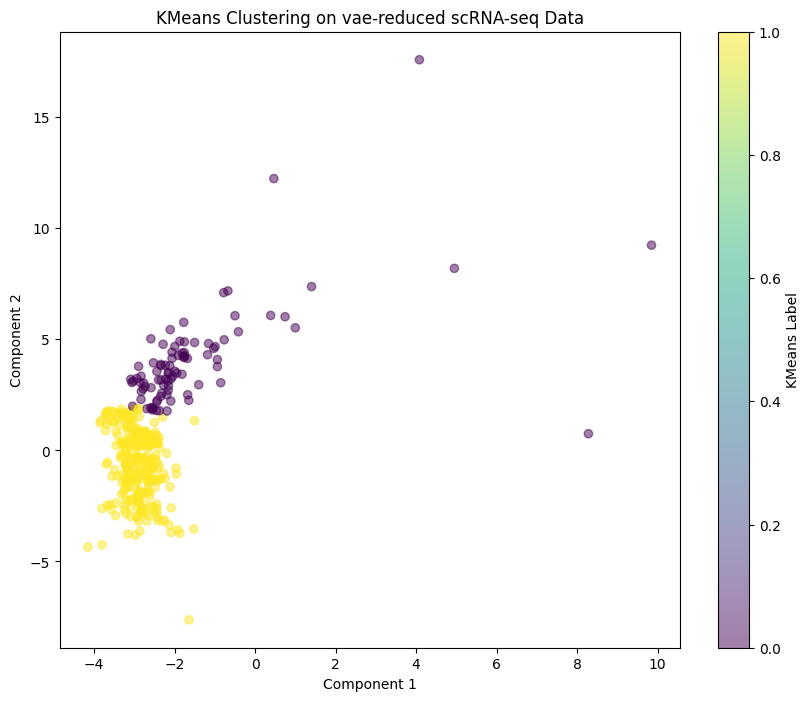

In [ ]:
X_chu_vae = prepare_vae_input(X_chu)
chu_vae_time = run_and_plot_2d(X_chu_vae, "vae", n_clusters=2)

In [ ]:
chu_results = evaluate_methods(
    X_chu, chu_labels, n_components=100
)
chu_results

Testing pca + KMeans...
(374, 100)
  pca results: {'AMI': np.float64(0.00799658653673257), 'ARI': 0.0194334129966733, 'Silhouette Score': np.float32(0.37948543), 'time': 1.4812266826629639}
Testing tsne + KMeans...
(374, 100)
  tsne results: {'AMI': np.float64(0.07594039463923412), 'ARI': 0.10403026840496381, 'Silhouette Score': np.float32(0.30763564), 'time': 12.533068656921387}
Testing umap + KMeans...
(374, 100)
  umap results: {'AMI': np.float64(0.10397748332725543), 'ARI': 0.06668503991552853, 'Silhouette Score': np.float32(0.43452656), 'time': 1.5439190864562988}

Overall Evaluation Results:
pca: {'AMI': np.float64(0.00799658653673257), 'ARI': 0.0194334129966733, 'Silhouette Score': np.float32(0.37948543), 'time': 1.4812266826629639}
tsne: {'AMI': np.float64(0.07594039463923412), 'ARI': 0.10403026840496381, 'Silhouette Score': np.float32(0.30763564), 'time': 12.533068656921387}
umap: {'AMI': np.float64(0.10397748332725543), 'ARI': 0.06668503991552853, 'Silhouette Score': np.float

In [ ]:
chu_vae_results = evaluate_methods(
    X_chu_vae, chu_labels, n_components=100, methods=("vae",)
)
chu_results.update(chu_vae_results)

Testing vae + KMeans...
(374, 100)
  vae results: {'AMI': np.float64(0.05380231244946865), 'ARI': 0.08076732981313856, 'Silhouette Score': np.float32(0.18875182), 'time': 12.451707601547241}


In [ ]:
plot_metric_results(chu_results)

## 7. Limitations and interpretation

- Saved outputs are single stochastic runs from the pre-cleanup notebook.
- The three datasets do not receive a common preprocessing protocol.
- The Chu subset differs from the H1/DEC comparison in Xiang et al.
- K-means is run once here, rather than 50 times as in the paper.
- The notebook computes AMI, while the paper reports NMI.
- No hyperparameter search, statistical significance test, or memory benchmark is implemented.
- Wall-clock timings are environment-dependent and cover the reduction step only.
- The project-specific VAE is not an exact implementation of the paper's VAE.